## Latency Metrics

In [1]:
from experiment_analysis import load_experiment_latencies

# Load experiment 3 from ./experiments/3
df = load_experiment_latencies(exp_id=1)

df.head()
df.describe(percentiles=[0.5, 0.9, 0.99])[[
    "end_to_end_s",
    "server_roundtrip_s",
    "router_queue_s",
    "vllm_compute_s",
]]


,end_to_end_s,server_roundtrip_s,router_queue_s,vllm_compute_s
count,200.000000,200.000000,200.000000,200.000000
mean,57.795467,56.181367,25.247258,25.497478
std,23.565479,22.952920,21.505428,23.440518
min,11.520083,11.103379,0.048732,0.491463
50%,61.875985,59.775285,24.027480,18.032927
90%,84.396536,82.213598,56.068665,62.693310
99%,112.464290,109.601380,64.114528,96.593244
max,119.024286,116.272725,64.920739,103.313918


In [2]:
df

,idx,req_id,send_failed,wait_wall_s,model_latency_s,finish_reason,prompt_tokens,completion_tokens,total_tokens,end_to_end_s,client_to_router_s,router_queue_s,router_to_sidecar_s,sidecar_queue_s,vllm_compute_s,sidecar_post_s,sidecar_to_router_s,router_post_result_s,server_roundtrip_s
0,36,98c124a6afae45a390cd8ca919f1c8ff,False,11.523510,11.066161,stop,381,3,384,11.520083,0.416704,0.433301,0.015895,0.000116,11.067440,0.000092,0.002458,0.000765,11.103379
1,12,d088e191fdcc4c69ad5d1e13b5cb8643,False,11.844347,11.608371,stop,319,3,322,11.842530,0.177175,0.211616,0.016350,0.000990,11.609356,0.000055,0.003003,0.001142,11.665354
2,7,82c1ff2cd40e4a8f9ba97da68b4bd7fb,False,11.906017,11.638632,stop,457,4,461,11.903915,0.085120,0.230718,0.016350,0.014168,11.639703,0.000048,0.002461,0.000406,11.818795
3,4,31cd5d2f81ed418d9f0e41607fecda7c,False,14.103474,13.847667,stop,450,3,453,14.100425,0.112029,0.228019,0.015296,0.000104,13.849318,0.000053,0.007111,0.000510,13.988396
4,33,9fd355c57efe46a78bf9cf4742e14718,False,14.045074,13.596580,stop,297,3,300,14.043286,0.404413,0.422870,0.015266,0.000103,13.598464,0.000065,0.004795,0.001712,13.638873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,38,c73683fb920b462783383d011ea1c5c6,False,103.938524,103.312795,length,413,2048,2461,103.935939,0.464399,0.590321,0.015841,0.011887,103.313918,0.000147,0.003269,0.000547,103.471540
196,142,4cdd4cea7d2b43bdbe985033db58c39b,False,104.595503,42.861517,stop,276,1482,1758,104.593334,3.253358,61.726610,0.000676,0.000038,42.862381,0.000082,0.003091,0.000450,101.339975
197,119,5a2f0cfd42c643dd9ac5131f3671781a,False,112.450006,57.699725,stop,380,1887,2267,112.447543,2.863583,54.741109,0.000721,0.000050,57.700992,0.000177,0.003970,0.000518,109.583960
198,137,925121e7ea7044cd9d7862b0bfeef1ba,False,114.124772,62.404224,length,382,2048,2430,114.122233,2.796322,51.712594,0.000625,0.000039,62.405280,0.000127,0.003056,0.000505,111.325910


In [3]:
from experiment_analysis import load_experiment_latencies
import pandas as pd

# ---- choose experiments ----
# experiments = [1, 2, 3, 4]
# experiments = [5, 6, 7, 8]
# experiments = [9, 10, 11, 12]
# experiments = [13, 14, 15, 16]
# experiments = [17, 18, 19, 20]
# experiments = [21, 22, 23, 24]
# experiments = [25, 26, 27, 28]
# experiments = [29, 30, 31, 32]
# experiments = [33, 34, 35, 36]
# experiments = [37, 38, 39, 40]
# experiments = [41, 42, 43, 44]
# experiments = [45, 46, 47, 48]
# experiments = [49, 50, 51, 52]
# experiments = [53, 54, 55, 56]
# experiments = [57, 58, 59, 60]
# experiments = [61, 62, 63, 64]
# experiments = [65, 66, 67, 68]
# experiments = [69, 70, 71, 72]
# experiments = [73, 74, 75, 76]
# experiments = [77, 78, 79, 80]
# experiments = [81, 82, 83, 84]
# experiments = [85, 86, 87, 88]
# experiments = [89, 90, 91, 92]
# experiments = [93, 94, 95, 96]
# experiments = [97, 98, 99, 100]
# experiments = [101, 102, 103, 104]
# experiments = [105, 106, 107, 108]
experiments = [109, 110, 111, 112]
# ----------------------------------------------

# Latency columns of interest
cols = [
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id)

    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )

    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison


,exp109_end_to_end_s,exp110_end_to_end_s,exp111_end_to_end_s,exp112_end_to_end_s
count,6417.000000,6526.000000,6292.000000,6426.000000
mean,153.151820,155.298681,162.516714,155.472670
std,61.033928,97.580264,107.265543,97.200627
min,0.219019,0.224852,0.219844,0.197182
50%,160.024586,142.442062,142.638217,138.838102
90%,198.799546,290.751978,335.341335,287.799071
99%,421.191529,398.843886,434.775415,401.170416
max,929.959026,649.228897,675.491460,623.952344



Average latencies per experiment:

Experiment 109:
  client_to_router_s          :    0.003 s
  router_queue_s              :  131.469 s
  router_to_sidecar_s         :    0.001 s
  sidecar_queue_s             :    0.000 s
  vllm_compute_s              :   21.675 s
  sidecar_post_s              :    0.000 s
  sidecar_to_router_s         :    0.005 s
  router_post_result_s        :    0.001 s
  SUM (components)            :  153.155 s

  Router post-result breakdown:
    router_result_handler_s   : 0.000001 s
    router_wakeup_s           : 0.000695 s
    router_response_build_s   : 0.000002 s
    router_after_return_stamp_s: 0.000000 s
    SUM (post breakdown)      : 0.000699 s
    router_post_result_s      : 0.000699 s
    DIFF (base - sum)         : 0.000000 s

  end_to_end_s                :  153.152 s

Experiment 110:
  client_to_router_s          :    0.004 s
  router_queue_s              :    0.028 s
  router_to_sidecar_s         :    0.017 s
  sidecar_queue_s             :  133

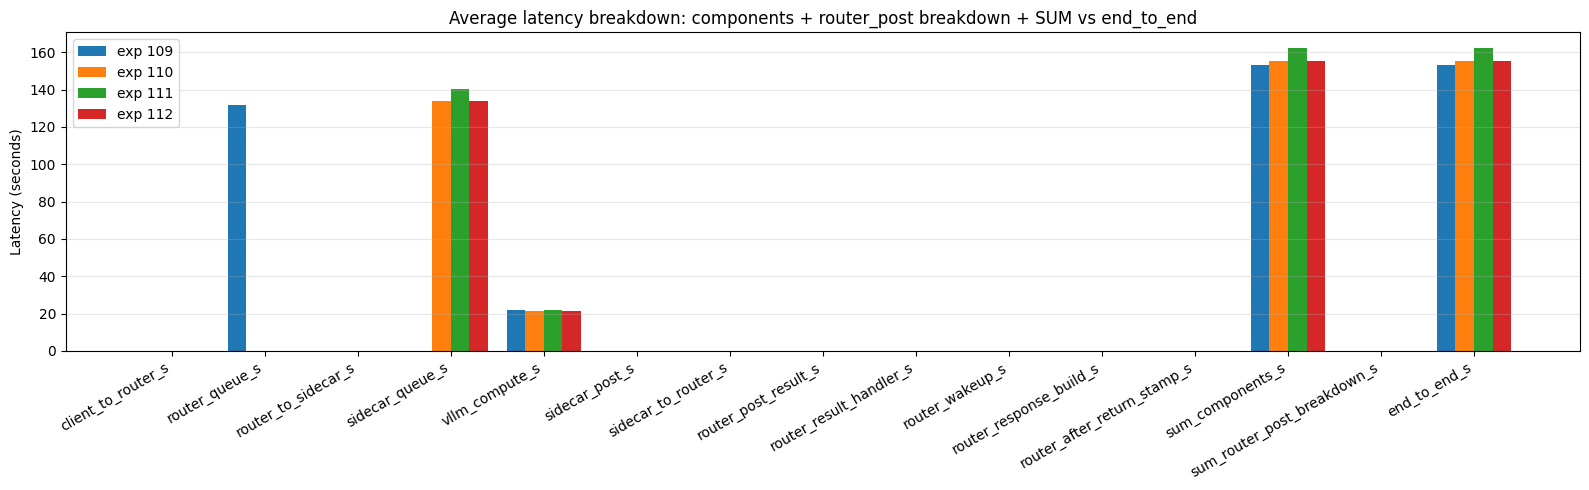

In [4]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt
import numpy as np

# ---- choose experiments ----
# experiments = [1, 2, 3, 4]
# experiments = [5, 6, 7, 8]
# experiments = [9, 10, 11, 12]
# experiments = [13, 14, 15, 16]
# experiments = [17, 18, 19, 20]
# experiments = [21, 22, 23, 24]
# experiments = [25, 26, 27, 28]
# experiments = [29, 30, 31, 32]
# experiments = [33, 34, 35, 36]
# experiments = [37, 38, 39, 40]
# experiments = [41, 42, 43, 44]
# experiments = [45, 46, 47, 48]
# experiments = [49, 50, 51, 52]
# experiments = [53, 54, 55, 56]
# experiments = [57, 58, 59, 60]
# experiments = [61, 62, 63, 64]
# experiments = [65, 66, 67, 68]
# experiments = [69, 70, 71, 72]
# experiments = [73, 74, 75, 76]
# experiments = [77, 78, 79, 80]
# experiments = [81, 82, 83, 84]
# experiments = [85, 86, 87, 88]
# experiments = [89, 90, 91, 92]
# experiments = [93, 94, 95, 96]
# experiments = [97, 98, 99, 100]
# experiments = [101, 102, 103, 104]
# experiments = [105, 106, 107, 108]
experiments = [109, 110, 111, 112]
# ---------------------------

# Non-overlapping latency components (base)
component_cols = [
    "client_to_router_s",
    "router_queue_s",
    "router_to_sidecar_s",
    "sidecar_queue_s",
    "vllm_compute_s",
    "sidecar_post_s",
    "sidecar_to_router_s",
    "router_post_result_s",
]

# NEW: router post-result breakdown (should sum ~ router_post_result_s when present)
router_post_breakdown_cols = [
    "router_result_handler_s",     # time spent inside /result handler (very small normally)
    "router_wakeup_s",             # waiter unblocked -> wait_for_result returns
    "router_response_build_s",     # build/merge trace/rename fields
    "router_after_return_stamp_s", # any last stamp after response object prepared (if you keep it)
]

# NEW: extra checkpoints (if you want them visible as standalone columns too)
# (These are timestamps in trace, not *_s metrics; only include if your loader exposes them as *_s already.)
# Keep this empty unless your load_experiment_latencies() converts them to seconds metrics.
extra_component_cols = [
    # e.g. "router_result_store_s", "router_enqueue_unblocked_s", ...
]

# End-to-end shown separately (NOT part of the sum)
e2e_col = "end_to_end_s"

# Plot order
plot_cols = (
    component_cols
    + router_post_breakdown_cols
    + extra_component_cols
    + ["sum_components_s", "sum_router_post_breakdown_s", e2e_col]
)

avg_by_exp = {}

for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id)

    # Base component means
    comp_means = df.reindex(columns=component_cols).mean(numeric_only=True)
    sum_components = float(comp_means.sum(skipna=True))

    # Router post breakdown means
    post_means = df.reindex(columns=router_post_breakdown_cols).mean(numeric_only=True)
    sum_post_breakdown = float(post_means.sum(skipna=True))

    # Optional extras
    extra_means = df.reindex(columns=extra_component_cols).mean(numeric_only=True)

    e2e_mean = float(df[e2e_col].mean()) if e2e_col in df.columns else float("nan")

    row = {}

    for k in component_cols:
        row[k] = float(comp_means.get(k, np.nan))

    for k in router_post_breakdown_cols:
        row[k] = float(post_means.get(k, np.nan))

    for k in extra_component_cols:
        row[k] = float(extra_means.get(k, np.nan))

    row["sum_components_s"] = sum_components
    row["sum_router_post_breakdown_s"] = sum_post_breakdown
    row[e2e_col] = e2e_mean

    avg_by_exp[exp_id] = row

# ---- print numbers ----
print("\nAverage latencies per experiment:\n")
for exp_id in experiments:
    r = avg_by_exp[exp_id]
    print(f"Experiment {exp_id}:")

    for k in component_cols:
        print(f"  {k:28s}: {r[k]:8.3f} s")

    print(f"  {'SUM (components)':28s}: {r['sum_components_s']:8.3f} s")
    print()

    print("  Router post-result breakdown:")
    for k in router_post_breakdown_cols:
        print(f"    {k:26s}: {r[k]:8.6f} s")
    print(f"    {'SUM (post breakdown)':26s}: {r['sum_router_post_breakdown_s']:8.6f} s")

    # Helpful comparison vs router_post_result_s if both exist
    base_post = r.get("router_post_result_s", np.nan)
    if not (np.isnan(base_post) or np.isnan(r["sum_router_post_breakdown_s"])):
        diff = base_post - r["sum_router_post_breakdown_s"]
        print(f"    {'router_post_result_s':26s}: {base_post:8.6f} s")
        print(f"    {'DIFF (base - sum)':26s}: {diff:8.6f} s")
    print()

    print(f"  {e2e_col:28s}: {r[e2e_col]:8.3f} s")
    print()

# ---- grouped bar plot ----
labels = plot_cols
x = np.arange(len(labels))
width = 0.8 / len(experiments)

plt.figure(figsize=(16, 5))

for i, exp_id in enumerate(experiments):
    vals = [avg_by_exp[exp_id].get(k, np.nan) for k in labels]
    plt.bar(x + i * width, vals, width, label=f"exp {exp_id}")

plt.xticks(
    x + width * (len(experiments) - 1) / 2,
    labels,
    rotation=30,
    ha="right"
)
plt.ylabel("Latency (seconds)")
plt.title("Average latency breakdown: components + router_post breakdown + SUM vs end_to_end")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


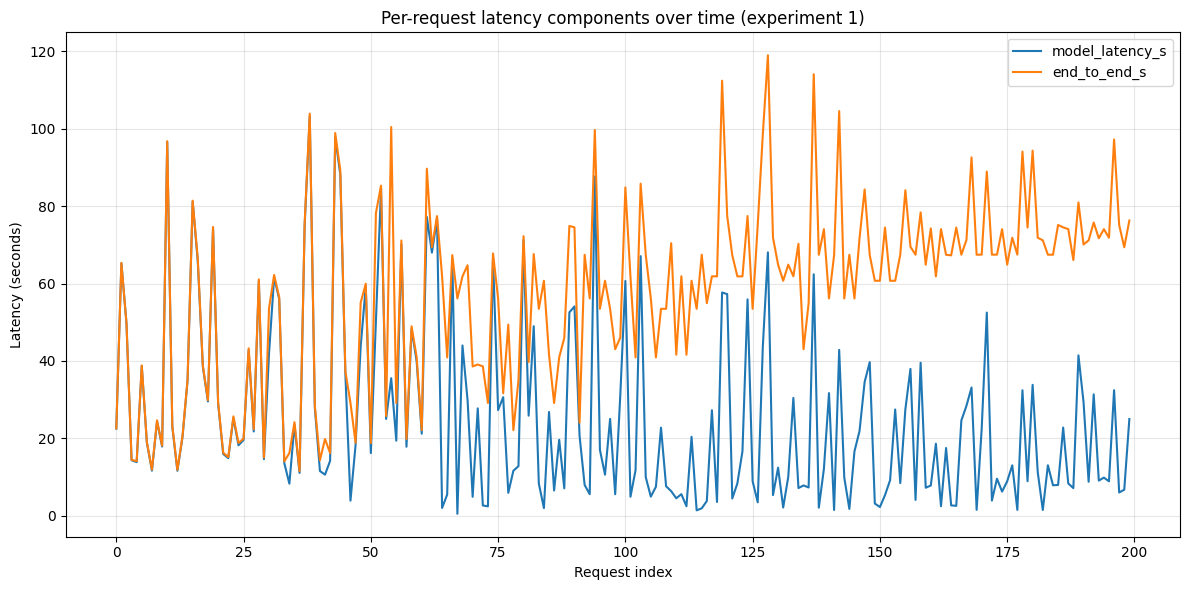

In [5]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiment ----
exp_id = 1
# ---------------------------

# Load and order by request index (or any monotonic field you prefer)
df = load_experiment_latencies(exp_id=exp_id).sort_values("idx").reset_index(drop=True)

# X-axis: request index (0, 1, 2, ...)
x = df["idx"]

# Latency metrics to plot over time
latency_cols = [
    "model_latency_s",
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "router_to_sidecar_s",
    # "sidecar_queue_s",
    # "vllm_compute_s",
]

plt.figure(figsize=(12, 6))

for col in latency_cols:
    if col in df.columns:
        plt.plot(x, df[col], label=col)

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(f"Per-request latency components over time (experiment {exp_id})")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


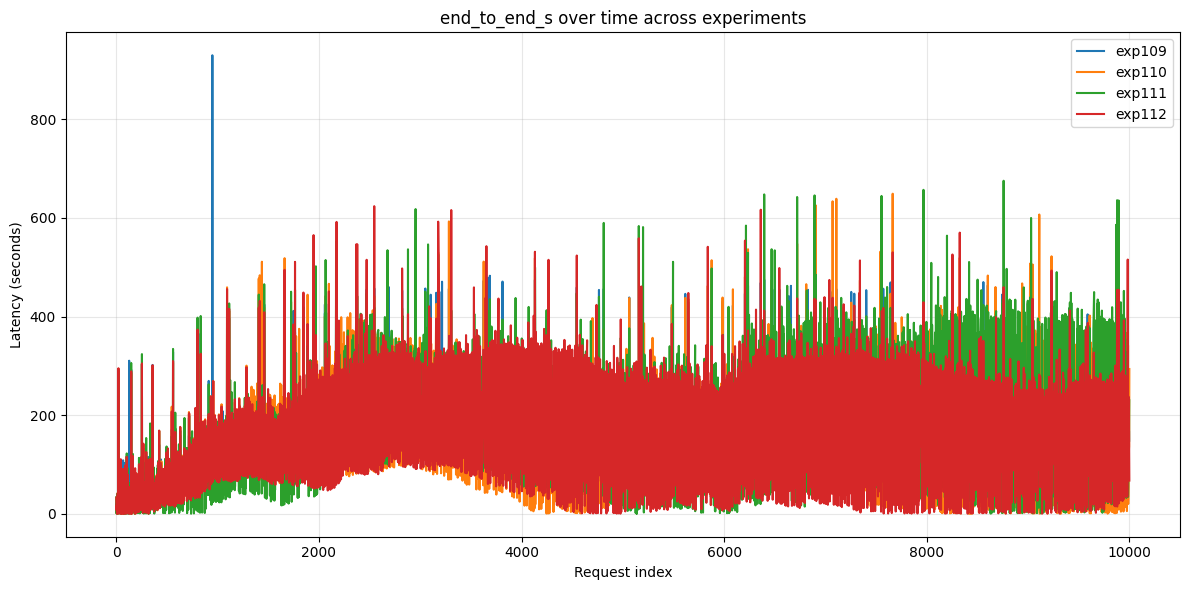

In [6]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiments ----
# experiments = [1, 2, 3, 4]
# experiments = [5, 6, 7, 8]
# experiments = [9, 10, 11, 12]
# experiments = [13, 14, 15, 16]
# experiments = [17, 18, 19, 20]
# experiments = [21, 22, 23, 24]
# experiments = [25, 26, 27, 28]
# experiments = [29, 30, 31, 32]
# experiments = [33, 34, 35, 36]
# experiments = [37, 38, 39, 40]
# experiments = [41, 42, 43, 44]
# experiments = [45, 46, 47, 48]
# experiments = [49, 50, 51, 52]
# experiments = [53, 54, 55, 56]
# experiments = [57, 58, 59, 60]
# experiments = [61, 62, 63, 64]
# experiments = [65, 66, 67, 68]
# experiments = [69, 70, 71, 72]
# experiments = [73, 74, 75, 76]
# experiments = [77, 78, 79, 80]
# experiments = [81, 82, 83, 84]
# experiments = [85, 86, 87, 88]
# experiments = [89, 90, 91, 92]
# experiments = [93, 94, 95, 96]
# experiments = [97, 98, 99, 100]
# experiments = [101, 102, 103, 104]
# experiments = [105, 106, 107, 108]
experiments = [109, 110, 111, 112]
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
metric = "end_to_end_s"          # total client → router → server → client
# metric = "server_roundtrip_s"  # router → vLLM → router
# metric = "router_queue_s"      # waiting time in router queue
# metric = "router_to_sidecar_s" # router → sidecar hop
# metric = "sidecar_queue_s"     # waiting time inside sidecar
# metric = "vllm_compute_s"      # actual model compute time
# metric = "router_post_result_s"
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(exp_id=exp_id)
        .sort_values("idx")
        .reset_index(drop=True)
    )

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(f"{metric} over time across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


## Throughput Metrics

In [7]:
from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
# experiments = [1, 2, 3, 4]
# experiments = [5, 6, 7, 8]
# experiments = [9, 10, 11, 12]
# experiments = [13, 14, 15, 16]
# experiments = [17, 18, 19, 20]
# experiments = [21, 22, 23, 24]
# experiments = [25, 26, 27, 28]
# experiments = [29, 30, 31, 32]
# experiments = [33, 34, 35, 36]
# experiments = [37, 38, 39, 40]
# experiments = [41, 42, 43, 44]
# experiments = [45, 46, 47, 48]
# experiments = [49, 50, 51, 52]
# experiments = [53, 54, 55, 56]
# experiments = [57, 58, 59, 60]
# experiments = [61, 62, 63, 64]
# experiments = [65, 66, 67, 68]
# experiments = [69, 70, 71, 72]
# experiments = [73, 74, 75, 76]
# experiments = [77, 78, 79, 80]
# experiments = [81, 82, 83, 84]
# experiments = [85, 86, 87, 88]
# experiments = [89, 90, 91, 92]
# experiments = [93, 94, 95, 96]
# experiments = [97, 98, 99, 100]
# experiments = [101, 102, 103, 104]
# experiments = [105, 106, 107, 108]
experiments = [109, 110, 111, 112]
# ----------------------------------------------

# Prometheus metric columns of interest
# (these are the fields inside each "samples" object in metrics.jsonl)
cols = [
    "gen_tokens_per_sec",
    "prefill_tokens_per_sec",
    "requests_running",
    # "requests_waiting",
    # "request_success_per_sec",
    # "request_failure_per_sec",
    # "preemptions_per_sec",
    # "gpu_kv_cache_usage_frac",
    # "cpu_kv_cache_usage_frac",
    #
    # vLLM latency hist averages (if your vLLM exposes them)
    "ttft_seconds_avg",
    "tpot_seconds_avg",
    # "e2e_latency_seconds_avg",
    # "queue_time_seconds_avg",
    # "inference_time_seconds_avg",
    # "prefill_time_seconds_avg",
    # "decode_time_seconds_avg",
    #
    # token distribution hists (averages)
    # "request_prompt_tokens_avg",
    # "request_generation_tokens_avg",
    # "request_max_generation_tokens_avg",
    #
    # spec decode (optional)
    # "spec_tokens_accepted_per_sec",
    # "spec_tokens_draft_per_sec",
    # "spec_tokens_emitted_per_sec",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    # Option 1 (simple): pool all instances together, treat each (tick,instance) as a sample
    # Option 2 (cluster view): sum across instances per tick, then describe the per-tick totals
    # Choose one; default below is cluster view because it's usually what you want when comparing runs.

    # ---- CLUSTER VIEW (recommended): sum across instances per tick ----
    # keeps time granularity, avoids overweighting runs with more instances in the file
    agg = prom.groupby("ts")[cols].sum(min_count=1).reset_index()

    # Describe only selected cols
    summary = (
        agg[cols]
        .describe(percentiles=percentiles)
        .add_prefix(f"exp{exp_id}_")
    )
    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison


,exp109_gen_tokens_per_sec,exp109_prefill_tokens_per_sec,exp109_requests_running,exp109_ttft_seconds_avg,exp109_tpot_seconds_avg,exp110_gen_tokens_per_sec,exp110_prefill_tokens_per_sec,exp110_requests_running,exp110_ttft_seconds_avg,exp110_tpot_seconds_avg,exp111_gen_tokens_per_sec,exp111_prefill_tokens_per_sec,exp111_requests_running,exp111_ttft_seconds_avg,exp111_tpot_seconds_avg,exp112_gen_tokens_per_sec,exp112_prefill_tokens_per_sec,exp112_requests_running,exp112_ttft_seconds_avg,exp112_tpot_seconds_avg
count,1027.000000,1027.000000,1027.000000,853.000000,1026.000000,1100.000000,1100.000000,1100.000000,1045.000000,1098.000000,1203.000000,1203.000000,1203.000000,1035.000000,1201.000000,1153.000000,1153.000000,1153.000000,976.000000,1151.000000
mean,1513.925336,213.292200,52.400195,2.426870,0.264705,1461.457526,213.860404,50.900000,2.080814,0.250731,1254.714729,177.275359,43.752286,1.952963,0.219106,1350.762327,197.275862,47.163053,2.208528,0.238532
std,586.621692,111.356704,21.055170,0.829480,0.040716,543.505242,100.595023,19.231244,0.750181,0.065098,672.358202,113.063229,23.855642,0.885239,0.090009,662.644172,117.233772,23.665187,0.798290,0.079682
min,0.000000,0.000000,0.000000,0.122297,0.027076,0.000000,0.000000,0.000000,0.193660,0.028828,0.000000,0.000000,0.000000,0.104664,0.031229,0.000000,0.000000,0.000000,0.135118,0.028715
50%,1781.896552,242.344828,63.000000,2.329081,0.278676,1742.482759,234.793103,62.000000,2.201205,0.275642,1714.665025,209.896552,60.000000,2.161108,0.275239,1725.827586,233.344828,61.000000,2.348695,0.276519
90%,1869.151724,323.937931,64.000000,2.941254,0.289391,1852.489655,323.006897,64.000000,2.832529,0.290022,1829.034483,309.579310,64.000000,2.917304,0.289110,1841.075862,316.386207,64.000000,2.949794,0.293148
99%,1938.993239,375.520517,64.000000,6.360631,0.303018,1886.967931,398.595517,64.000000,3.785819,0.301723,1888.942069,382.828768,64.000000,3.598718,0.300800,1881.328276,414.667324,64.000000,3.858116,0.304230
max,1961.344828,400.306903,64.000000,10.071278,0.308020,1906.344828,436.008621,64.000000,4.144821,0.307123,1905.275862,415.896552,64.000000,4.427297,0.305923,1899.413793,447.620690,64.000000,5.951794,0.328004


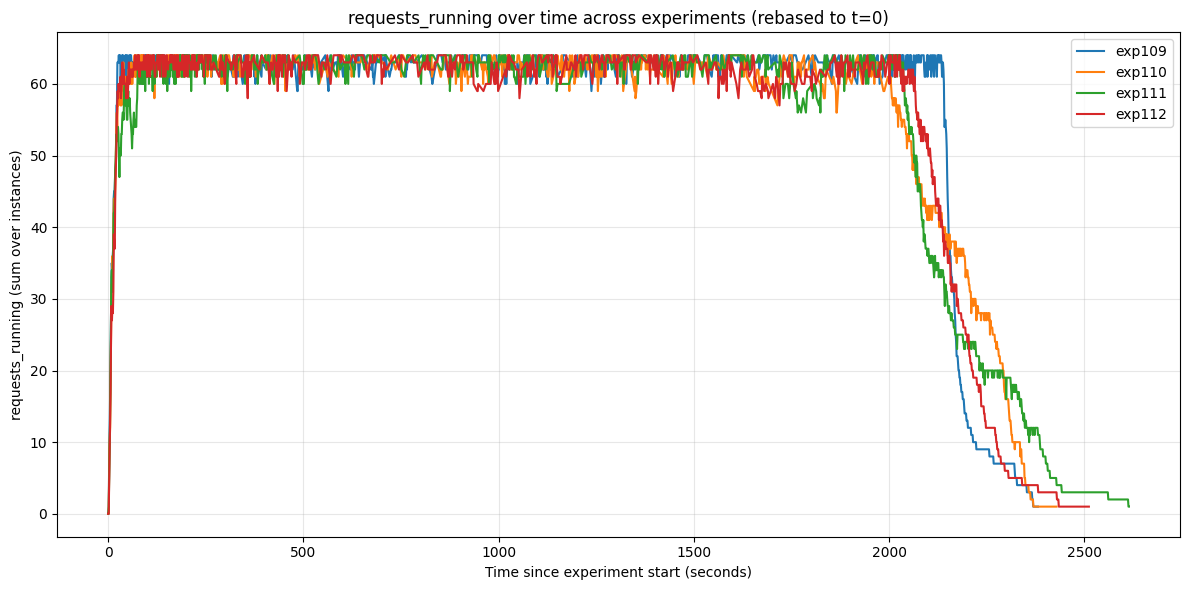

In [8]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt

# ---- choose experiments ----
# experiments = [1, 2, 3, 4]
# experiments = [5, 6, 7, 8]
# experiments = [9, 10, 11, 12]
# experiments = [13, 14, 15, 16]
# experiments = [17, 18, 19, 20]
# experiments = [21, 22, 23, 24]
# experiments = [25, 26, 27, 28]
# experiments = [29, 30, 31, 32]
# experiments = [33, 34, 35, 36]
# experiments = [37, 38, 39, 40]
# experiments = [41, 42, 43, 44]
# experiments = [45, 46, 47, 48]
# experiments = [49, 50, 51, 52]
# experiments = [53, 54, 55, 56]
# experiments = [57, 58, 59, 60]
# experiments = [61, 62, 63, 64]
# experiments = [65, 66, 67, 68]
# experiments = [69, 70, 71, 72]
# experiments = [73, 74, 75, 76]
# experiments = [77, 78, 79, 80]
# experiments = [81, 82, 83, 84]
# experiments = [85, 86, 87, 88]
# experiments = [89, 90, 91, 92]
# experiments = [93, 94, 95, 96]
# experiments = [97, 98, 99, 100]
# experiments = [101, 102, 103, 104]
# experiments = [105, 106, 107, 108]
experiments = [109, 110, 111, 112]

# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
metric = "requests_running"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "request_success_per_sec"
# metric = "request_failure_per_sec"
# metric = "preemptions_per_sec"
# metric = "gpu_kv_cache_usage_frac"
# metric = "cpu_kv_cache_usage_frac"
# metric = "requests_waiting"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# metric = "queue_time_seconds_avg"
# metric = "inference_time_seconds_avg"
# metric = "prefill_time_seconds_avg"
# metric = "decode_time_seconds_avg"
# metric = "request_prompt_tokens_avg"
# metric = "request_generation_tokens_avg"
# metric = "request_max_generation_tokens_avg"
# metric = "spec_tokens_accepted_per_sec"
# metric = "spec_tokens_draft_per_sec"
# metric = "spec_tokens_emitted_per_sec"

# -----------------------------------------------

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Rebase time: each experiment starts at t=0
    t0 = prom["ts"].min()
    prom["t_rel_s"] = (prom["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick
    if agg_mode == "sum":
        series = prom.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances)"
    else:
        series = prom.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances)"

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


## Token Length Distribution

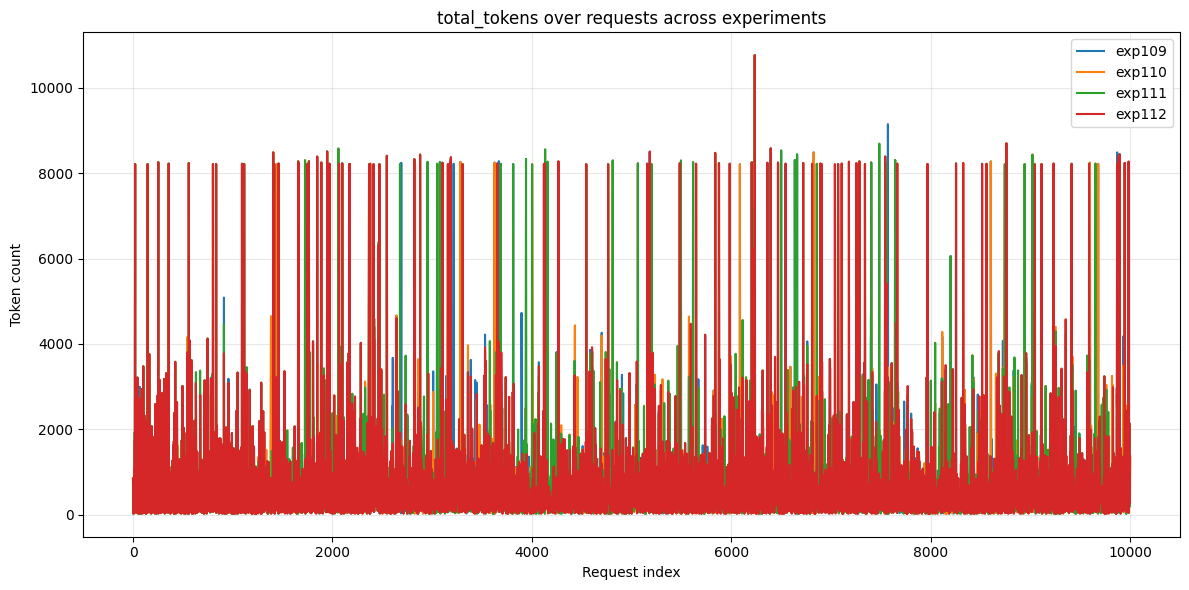

In [9]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiments ----
# experiments = [1, 2, 3, 4]
# experiments = [5, 6, 7, 8]
# experiments = [9, 10, 11, 12]
# experiments = [13, 14, 15, 16]
# experiments = [17, 18, 19, 20]
# experiments = [21, 22, 23, 24]
# experiments = [25, 26, 27, 28]
# experiments = [29, 30, 31, 32]
# experiments = [33, 34, 35, 36]
# experiments = [37, 38, 39, 40]
# experiments = [41, 42, 43, 44]
# experiments = [45, 46, 47, 48]
# experiments = [49, 50, 51, 52]
# experiments = [53, 54, 55, 56]
# experiments = [57, 58, 59, 60]
# experiments = [61, 62, 63, 64]
# experiments = [65, 66, 67, 68]
# experiments = [69, 70, 71, 72]
# experiments = [73, 74, 75, 76]
# experiments = [77, 78, 79, 80]
# experiments = [81, 82, 83, 84]
# experiments = [85, 86, 87, 88]
# experiments = [89, 90, 91, 92]
# experiments = [93, 94, 95, 96]
# experiments = [97, 98, 99, 100]
# experiments = [101, 102, 103, 104]
# experiments = [105, 106, 107, 108]
experiments = [109, 110, 111, 112]
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "prompt_tokens"        # input length
# metric = "completion_tokens"  # output length
metric = "total_tokens"       # input + output
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(exp_id=exp_id)
        .sort_values("idx")
        .reset_index(drop=True)
    )

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Token count")
plt.title(f"{metric} over requests across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


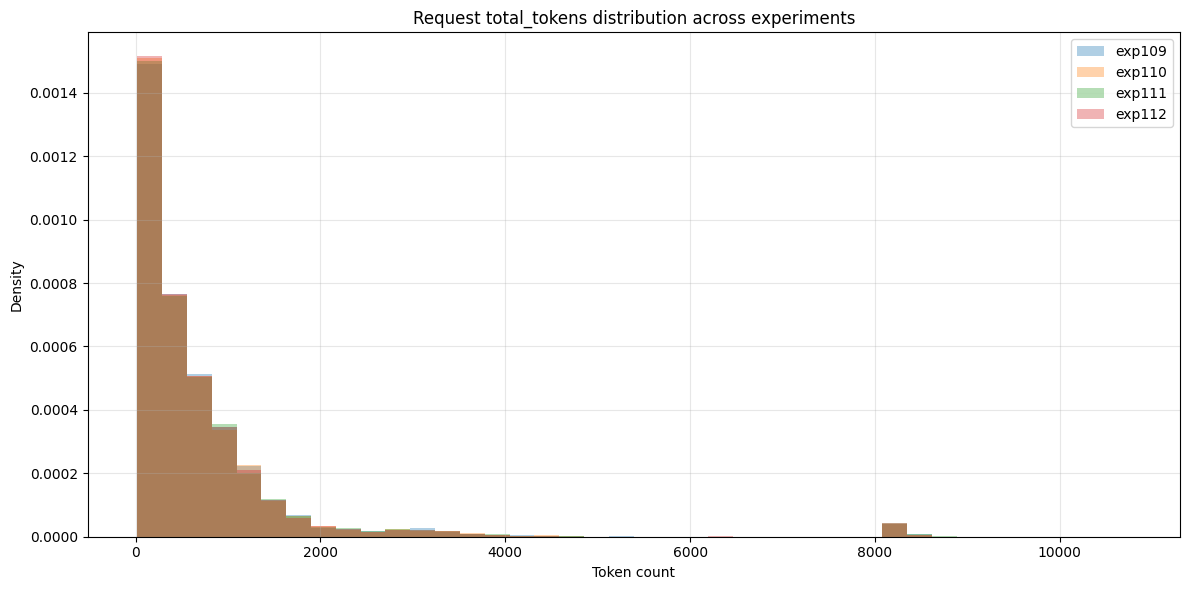

In [10]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# experiments = [1, 2, 3, 4]
# experiments = [5, 6, 7, 8]
# experiments = [9, 10, 11, 12]
# experiments = [13, 14, 15, 16]
# experiments = [17, 18, 19, 20]
# experiments = [21, 22, 23, 24]
# experiments = [25, 26, 27, 28]
# experiments = [29, 30, 31, 32]
# experiments = [33, 34, 35, 36]
# experiments = [37, 38, 39, 40]
# experiments = [41, 42, 43, 44]
# experiments = [45, 46, 47, 48]
# experiments = [49, 50, 51, 52]
# experiments = [53, 54, 55, 56]
# experiments = [57, 58, 59, 60]
# experiments = [61, 62, 63, 64]
# experiments = [65, 66, 67, 68]
# experiments = [69, 70, 71, 72]
# experiments = [73, 74, 75, 76]
# experiments = [77, 78, 79, 80]
# experiments = [81, 82, 83, 84]
# experiments = [85, 86, 87, 88]
# experiments = [89, 90, 91, 92]
# experiments = [93, 94, 95, 96]
# experiments = [97, 98, 99, 100]
# experiments = [101, 102, 103, 104]
# experiments = [105, 106, 107, 108]
experiments = [109, 110, 111, 112]
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "prompt_tokens"        # input length distribution
# metric = "completion_tokens"  # output length distribution
metric = "total_tokens"       # input + output distribution
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id)

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    values = pd.to_numeric(df[metric], errors="coerce").dropna()
    if values.empty:
        print(f"Skipping exp{exp_id}: {metric} all NaN")
        continue

    plt.hist(
        values,
        bins=40,
        density=True,     # normalize so experiments are comparable
        alpha=0.35,
        label=f"exp{exp_id}",
    )

plt.xlabel("Token count")
plt.ylabel("Density")
plt.title(f"Request {metric} distribution across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


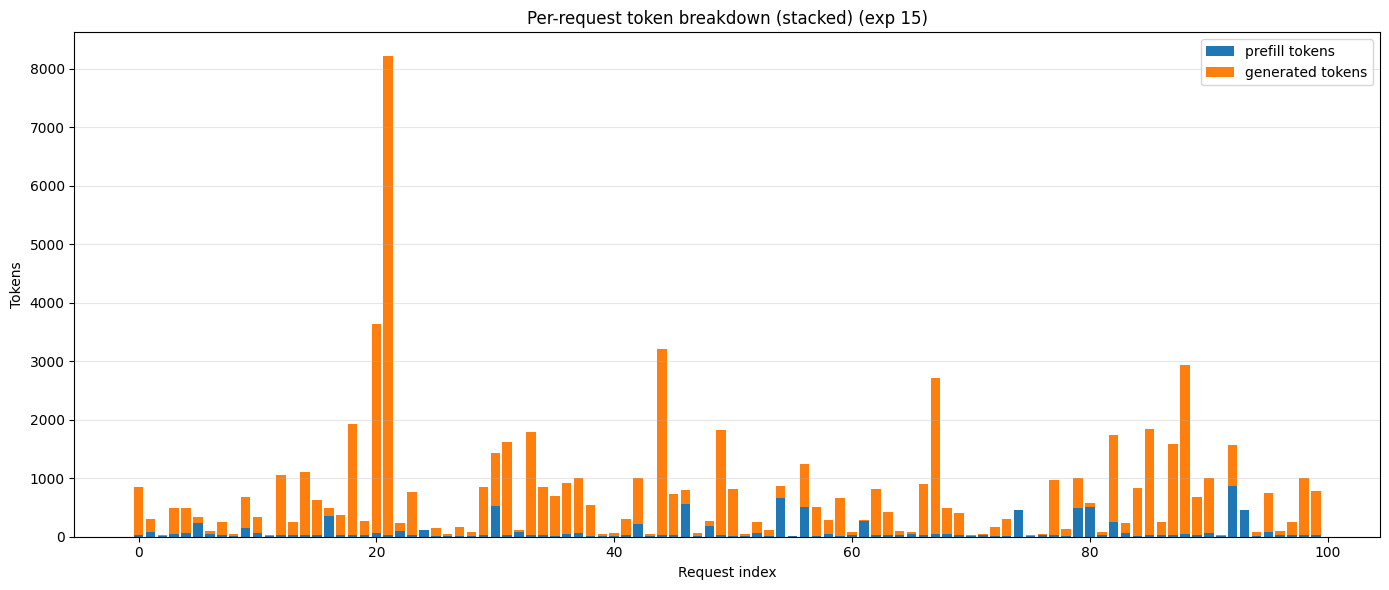

In [11]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose ONE experiment ----
exp_id = 15
# ------------------------------

# ---- plotting controls ----
max_requests_to_plot = 100   # set None to plot all (can get slow/cluttered)

# ---- choose what to show (uncomment as needed) ----
show_prefill = True
show_generated = True
# show_prefill = True;  show_generated = False   # only prefill
# show_prefill = False; show_generated = True    # only generated
# -----------------------------------------------

df = (
    load_experiment_latencies(exp_id=exp_id)
    .sort_values("idx")
    .reset_index(drop=True)
)

# Pull columns if present
x = pd.to_numeric(df.get("idx"), errors="coerce")

prefill = None
gen = None

if show_prefill:
    prefill = pd.to_numeric(df.get("prompt_tokens"), errors="coerce")
    if "prompt_tokens" not in df.columns:
        print("WARN: prompt_tokens not found; disabling prefill plot.")
        show_prefill = False

if show_generated:
    # support either completion_tokens or output_tokens naming
    if "completion_tokens" in df.columns:
        gen = pd.to_numeric(df["completion_tokens"], errors="coerce")
    elif "output_tokens" in df.columns:
        gen = pd.to_numeric(df["output_tokens"], errors="coerce")
    else:
        print("WARN: completion_tokens/output_tokens not found; disabling generated plot.")
        show_generated = False

if not show_prefill and not show_generated:
    raise RuntimeError("Nothing to plot: both prefill and generated are disabled or missing.")

# Build mask of valid rows depending on what is enabled
mask = x.notna()
if show_prefill and prefill is not None:
    mask &= prefill.notna()
if show_generated and gen is not None:
    mask &= gen.notna()

x = x[mask].astype(int).values
prefill_vals = prefill[mask].values if (show_prefill and prefill is not None) else None
gen_vals = gen[mask].values if (show_generated and gen is not None) else None

# Trim if requested
if max_requests_to_plot is not None and len(x) > max_requests_to_plot:
    x = x[:max_requests_to_plot]
    if prefill_vals is not None:
        prefill_vals = prefill_vals[:max_requests_to_plot]
    if gen_vals is not None:
        gen_vals = gen_vals[:max_requests_to_plot]

plt.figure(figsize=(14, 6))

# Plot variants
if show_prefill and show_generated:
    # Stacked bars: prefill at bottom, generated on top
    plt.bar(x, prefill_vals, label="prefill tokens")
    plt.bar(x, gen_vals, bottom=prefill_vals, label="generated tokens")
    title = "Per-request token breakdown (stacked)"
elif show_prefill:
    plt.bar(x, prefill_vals, label="prefill tokens")
    title = "Per-request prefill tokens"
else:
    plt.bar(x, gen_vals, label="generated tokens")
    title = "Per-request generated tokens"

plt.xlabel("Request index")
plt.ylabel("Tokens")
plt.title(f"{title} (exp {exp_id})")
plt.legend(loc="upper right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()


In [12]:
from pathlib import Path
import json
import pandas as pd

# ---- choose experiments ----
# experiments = [1, 2, 3, 4]
# experiments = [5, 6, 7, 8]
# experiments = [9, 10, 11, 12]
# experiments = [13, 14, 15, 16]
# experiments = [17, 18, 19, 20]
# experiments = [21, 22, 23, 24]
# experiments = [25, 26, 27, 28]
# experiments = [29, 30, 31, 32]
# experiments = [33, 34, 35, 36]
# experiments = [37, 38, 39, 40]
# experiments = [41, 42, 43, 44]
# experiments = [45, 46, 47, 48]
# experiments = [49, 50, 51, 52]
# experiments = [53, 54, 55, 56]
# experiments = [57, 58, 59, 60]
# experiments = [61, 62, 63, 64]
# experiments = [65, 66, 67, 68]
# experiments = [69, 70, 71, 72]
# experiments = [73, 74, 75, 76]
# experiments = [77, 78, 79, 80]
# experiments = [81, 82, 83, 84]
# experiments = [85, 86, 87, 88]
# experiments = [89, 90, 91, 92]
# experiments = [93, 94, 95, 96]
# experiments = [97, 98, 99, 100]
# experiments = [101, 102, 103, 104]
# experiments = [105, 106, 107, 108]
experiments = [109, 110, 111, 112]
# ----------------------------


def count_requests(exp_id, experiments_root="experiments"):
    exp_dir = Path(experiments_root) / str(exp_id)
    logs_path = exp_dir / "logs.json"

    if not logs_path.exists():
        raise FileNotFoundError(f"logs.json not found for experiment {exp_id}")

    total = 0
    success = 0
    send_failed = 0

    with logs_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)
            total += 1

            if rec.get("send_failed", False):
                send_failed += 1
            else:
                success += 1

    return {
        "experiment": exp_id,
        "total_requests": total,
        "successful_requests": success,
        "connection_failed_requests": send_failed,
        "success_rate_pct": 100.0 * success / total if total > 0 else 0.0,
        "failure_rate_pct": 100.0 * send_failed / total if total > 0 else 0.0,
    }


rows = []
for exp_id in experiments:
    rows.append(count_requests(exp_id))

df_counts = pd.DataFrame(rows)
df_counts


,experiment,total_requests,successful_requests,connection_failed_requests,success_rate_pct,failure_rate_pct
0,109,10000,6417,3583,64.17,35.83
1,110,10000,6526,3474,65.26,34.74
2,111,10000,6292,3708,62.92,37.08
3,112,10000,6426,3574,64.26,35.74


In [13]:
from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
experiments = [103]
# ----------------------------------------------

percentiles = [0.5, 0.9, 0.99]

# NEW metrics only
ROUTER_COLS = [
    "router_queue_length",
    "router_admission_rps",
    "router_outgoing_rps",
]

SIDECAR_COLS = [
    "sidecar_queue_length",
    "sidecar_received_rps",
    "sidecar_completed_rps",
]

def _port_of_instance(inst: str):
    try:
        _host, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

def _summarize_cluster_view(df: pd.DataFrame, cols: list[str], exp_id: int, label: str):
    """
    Cluster-view: aggregate across instances per tick, then describe across time.
    """
    if df.empty:
        return None, None

    cols = [c for c in cols if c in df.columns]
    if not cols:
        return None, None

    # per-tick aggregate across instances
    agg = df.groupby("ts")[cols].sum(min_count=1).reset_index()

    summary = (
        agg[cols]
        .describe(percentiles=percentiles)
        .add_prefix(f"exp{exp_id}_{label}_")
    )

    # % of ticks where metric is non-null after aggregation
    coverage = (
        (agg[cols].notna().mean() * 100.0)
        .to_frame(name=f"exp{exp_id}_{label}_non_null_pct")
    )

    return summary, coverage

summaries = []
coverages = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    # Split by target type (so we don't mix 8080 + 9000 in the same aggregation)
    router_df = _subset_by_port(prom, 8080)
    sidecar_df = _subset_by_port(prom, 9000)

    s_router, c_router = _summarize_cluster_view(router_df, ROUTER_COLS, exp_id, "router")
    s_sidecar, c_sidecar = _summarize_cluster_view(sidecar_df, SIDECAR_COLS, exp_id, "sidecar")

    if s_router is None:
        print(f"[WARN] exp{exp_id}: no router (8080) samples found")
    else:
        summaries.append(s_router)
        coverages.append(c_router)

    if s_sidecar is None:
        print(f"[WARN] exp{exp_id}: no sidecar (9000) samples found")
    else:
        summaries.append(s_sidecar)
        coverages.append(c_sidecar)

comparison = pd.concat(summaries, axis=1) if summaries else pd.DataFrame()
coverage_comparison = pd.concat(coverages, axis=1) if coverages else pd.DataFrame()

comparison


[WARN] exp103: no router (8080) samples found
[WARN] exp103: no sidecar (9000) samples found


""
